# Question 2 Clustering: Average Trait Model
This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_clustering_avg.csv`.

This notebook clusters dog breeds using the individual AKC trait ratings with grouped average features: family life, physical, social, and personality.

In [1]:
from pathlib import Path
import sys

import pandas as pd

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.clustering.kmeans import kmeans_main
from models.clustering.clustering_analysis_utils import (
    akc_group_traits_table,
    cluster_summary_with_akc,
    plot_cluster_composition,
    predictions_output,
)
from models.clustering.evaluation import print_cluster_report

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_clustering_avg.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question2" / "clustering_avg_predictions.csv"

In [3]:
data, labels, centroids, ground_truth = kmeans_main(DATA_PATH, 7, 0.000000001, 7)

PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_results = predictions_output(DATA_PATH, labels, PREDICTION_OUTPUT_PATH, centroids)

print_cluster_report(data, labels, ground_truth)
cluster_summary = cluster_summary_with_akc(prediction_results, data, labels, DATA_PATH, centroids)
cluster_summary

Overall Metrics
Overall silhouette score: 0.19
Rand Index: 0.76
Average radius / average intercluster distance: 0.92


Trait Cluster,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Metric,,,,,,,
Cluster Size,33,38,20,19,40,30,22
Most Common AKC Group,Working Group,Herding Group,Non-Sporting Group,Sporting Group,Terrier Group,Terrier Group,Sporting Group
Most Common AKC Group Count,14,11,6,7,12,9,8
Predicted AKC Group,Working Group,Terrier Group,Non-Sporting Group,Sporting Group,Hound Group,Sporting Group,Sporting Group
Distance To Predicted AKC Group,0.6,0.36,0.7,0.84,0.8,0.76,0.54
AKC Rand Index,0.7,0.63,0.76,0.69,0.64,0.66,0.69
Silhouette Score,0.17,0.17,0.11,0.24,0.16,0.26,0.21
Radius,1.38,1.08,1.29,1.04,1.3,1.1,1.11


### Cluster Centroids vs AKC Group Traits Averages


In [4]:
cluster_traits = pd.DataFrame(
    centroids.round(2).T,
    index=data.columns,
    columns=[f"Cluster {i}" for i in range(1, centroids.shape[0] + 1)]
)
cluster_traits.index.name = "Trait"
cluster_traits

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7
Trait,,,,,,,
Family Life,3.34,3.82,4.67,4.89,3.42,4.21,4.45
Physical,2.70,1.87,2.27,2.21,1.72,2.33,2.74
Social,3.46,3.59,3.80,3.95,3.29,4.32,3.48
Personality,3.41,3.88,2.98,4.21,3.11,4.22,3.56


In [5]:
group_traits = akc_group_traits_table(DATA_PATH)
group_traits

AKC Group,Herding Group,Hound Group,Non-Sporting Group,Sporting Group,Terrier Group,Toy Group,Working Group
Trait,,,,,,,
Family Life,3.75,4.08,4.08,4.22,3.86,4.03,3.85
Physical,2.26,1.97,2.22,2.38,1.94,2.00,2.61
Social,3.59,3.30,3.82,3.67,3.77,3.85,3.75
Personality,3.92,3.48,3.35,3.82,3.57,3.39,3.52


### How well do trait-based clusters line up with AKC Groups?


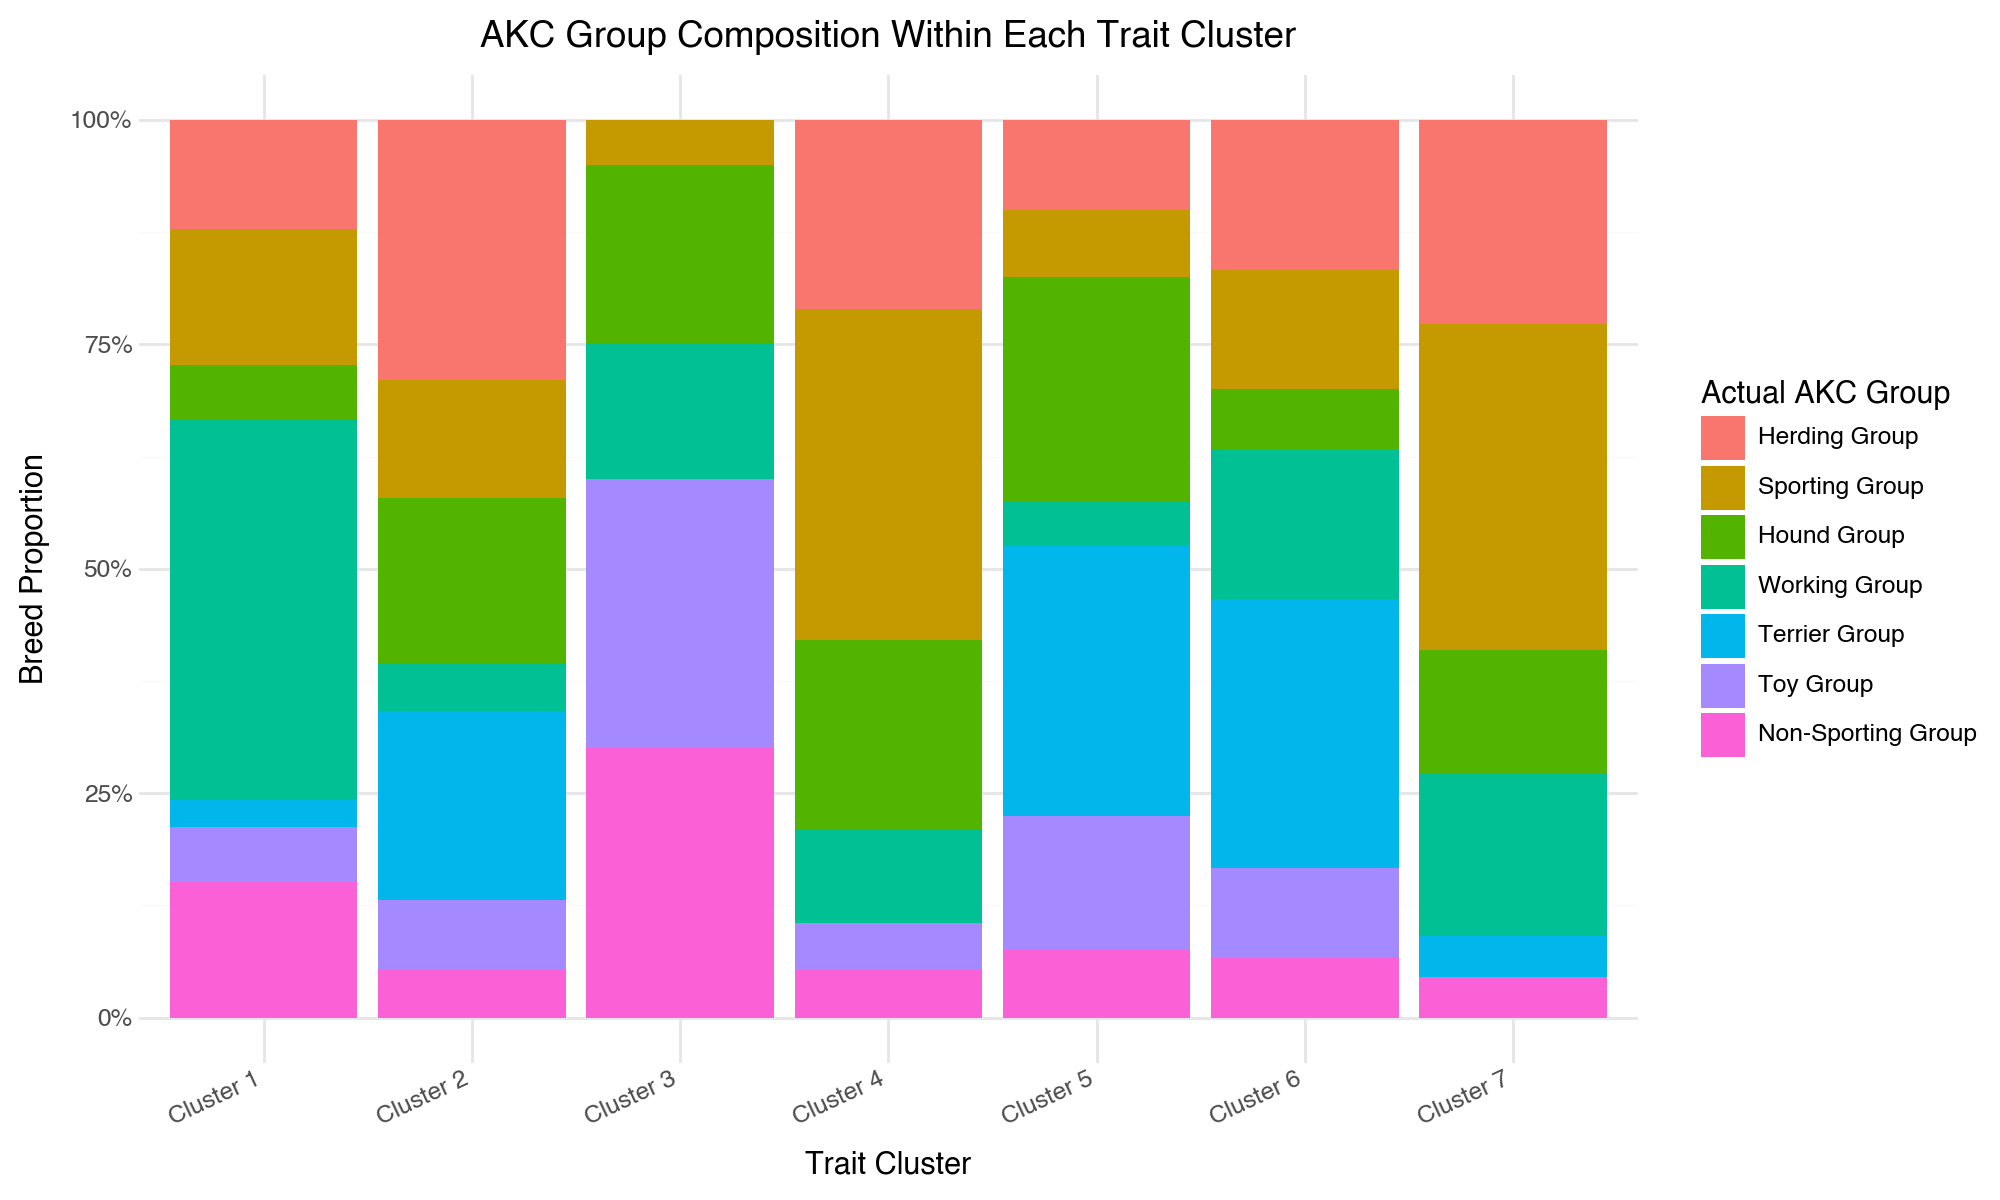

In [6]:
plot_cluster_composition(prediction_results)


## Prediction Output

This
table
saves
each
breed
's assigned cluster with its average rank, popularity tier, and AKC group.

In [7]:
prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Trait Cluster,Predicted AKC Group,Actual AKC Group,Distance To Predicted AKC Group,Correct AKC Prediction
0,Affenpinscher,Cluster 1,Working Group,Toy Group,0.60,False
1,Afghan Hound,Cluster 5,Hound Group,Hound Group,0.80,True
2,Airedale Terrier,Cluster 5,Hound Group,Terrier Group,0.80,False
3,Akita,Cluster 1,Working Group,Working Group,0.60,True
4,Alaskan Malamute,Cluster 1,Working Group,Working Group,0.60,True
...,...,...,...,...,...,...
197,Wire Fox Terrier,Cluster 6,Sporting Group,Terrier Group,0.76,False
198,Wirehaired Pointing Griffon,Cluster 6,Sporting Group,Sporting Group,0.76,True
199,Wirehaired Vizsla,Cluster 6,Sporting Group,Sporting Group,0.76,True
200,Xoloitzcuintli,Cluster 2,Terrier Group,Non-Sporting Group,0.36,False
